# Implementation of polynomial regression

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

In [2]:
# load the dataset
data=pd.read_csv("ice_cream_selling_data.csv")
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [3]:
#split independent features and dependent variable 
X=data.iloc[:,0].values.reshape(-1,1)
y=data.iloc[:,1].values
print(X)

[[-4.66226268]
 [-4.31655945]
 [-4.21398477]
 [-3.94966109]
 [-3.57855372]
 [-3.4557117 ]
 [-3.10844012]
 [-3.08130332]
 [-2.67246083]
 [-2.65228679]
 [-2.65149803]
 [-2.288264  ]
 [-2.11186969]
 [-1.81893761]
 [-1.66034773]
 [-1.32637898]
 [-1.17312327]
 [-0.77333004]
 [-0.6737528 ]
 [-0.14963487]
 [-0.0361565 ]
 [-0.03389529]
 [ 0.0086077 ]
 [ 0.14924457]
 [ 0.68878091]
 [ 0.69359887]
 [ 0.87490503]
 [ 1.02418081]
 [ 1.24071162]
 [ 1.35981267]
 [ 1.74000001]
 [ 1.85055193]
 [ 1.99931037]
 [ 2.0751006 ]
 [ 2.31859124]
 [ 2.471946  ]
 [ 2.78483646]
 [ 2.83176021]
 [ 2.95993209]
 [ 3.02087431]
 [ 3.21136614]
 [ 3.27004407]
 [ 3.31607252]
 [ 3.33593241]
 [ 3.61077848]
 [ 3.70405744]
 [ 4.13086796]
 [ 4.13353379]
 [ 4.89903151]]


In [4]:
print(y)

[41.84298632 34.66111954 39.38300088 37.53984488 32.28453119 30.00113848
 22.63540128 25.36502221 19.22697005 20.27967918 13.2758285  18.12399121
 11.21829447 10.01286785 12.61518115 10.95773134  6.68912264  9.39296866
  5.21016261  4.67364254  0.32862552  0.89760319  3.16560001  1.93141603
  2.57678224  4.62568946  0.78997365  2.31380636  1.29236081  0.95311531
  3.78257014  4.8579878   8.94382321  8.17073494  7.41209403 10.33663062
 15.99661997 12.56823739 21.34291574 20.11441346 22.8394055  16.98327874
 25.14208223 26.10474041 28.91218793 17.84395652 34.53074274 27.69838335
 41.51482194]


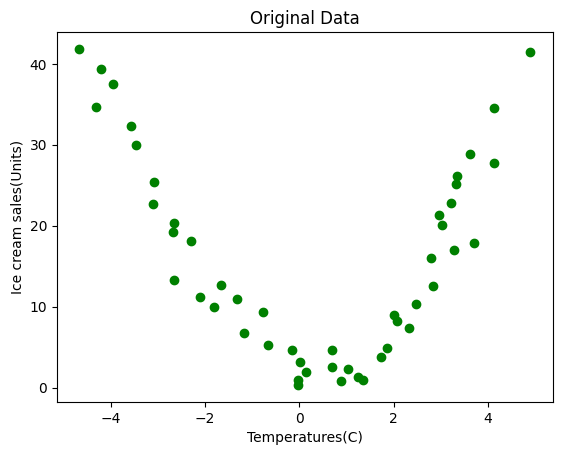

In [5]:
#Visulatzation the oringing point
plt.scatter(X, y, color="green")
plt.xlabel("Temperatures(C)") 
plt.ylabel("Ice cream sales(Units)") 
plt.title("Original Data") 
plt.show()

In [6]:
# Create a polynomial features object degree=2
deg=2 #degree of the polynomial
polyno_features=PolynomialFeatures(degree=deg)

In [7]:
#now transform the input data into polynomial features
X_poly=polyno_features.fit_transform(X)

In [8]:
#model training
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
#Now, fit the model
lr.fit(X_poly,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
#Model prediction and testing
y_pred=lr.predict(X_poly)
df=pd.DataFrame({'Actual Values':y,'Predicted Values':y_pred})
print(df)

    Actual Values  Predicted Values
0       41.842986         46.564507
1       34.661120         40.600548
2       39.383001         38.915089
3       37.539845         34.749272
4       32.284531         29.331940
5       30.001138         27.649735
6       22.635401         23.192862
7       25.365022         22.863178
8       19.226970         18.222266
9       20.279679         18.009098
10      13.275828         18.000794
11      18.123991         14.418541
12      11.218294         12.853070
13      10.012868         10.504868
14      12.615181          9.364587
15      10.957731          7.264266
16       6.689123          6.437055
17       9.392969          4.683654
18       5.210163          4.337906
19       4.673643          3.116139
20       0.328626          2.983983
21       0.897603          2.981829
22       3.165600          2.944811
23       1.931416          2.869446
24       2.576782          3.251711
25       4.625689          3.259923
26       0.789974          3

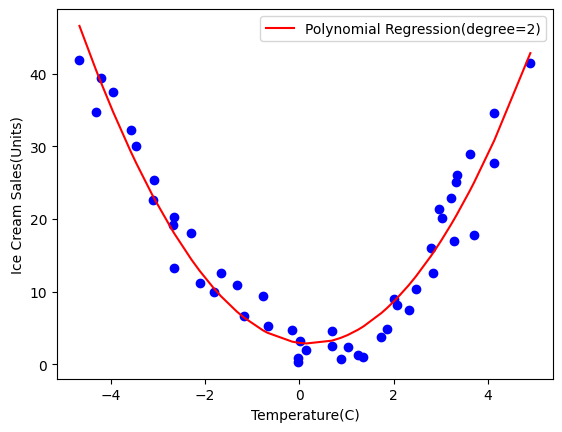

In [12]:
#Visulize the polynomial regression result
plt.scatter(X,y, color="blue")
plt.plot(X,y_pred, color='red', label=f'Polynomial Regression(degree={deg})')
plt.xlabel("Temperature(C)")
plt.ylabel("Ice Cream Sales(Units)")
plt.legend()
plt.show()

In [13]:
#model prediction for New Data
#predict a new value
X_new=np.array([[1.9929]]) #example value to predict
X_new_poly = polyno_features.transform(X_new)
y_new_pred=lr.predict(X_new_poly)
print(y_new_pred)

[8.57450466]
